In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
df = pd.read_csv("../data/bank-additional/bank-additional-full.csv", sep=";")
df = df.drop(columns=["duration"], errors="ignore")

print(df.shape)
print(df.head())
print(df.dtypes)
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))
print(df.isna().sum().sort_values(ascending=False))
print(df.select_dtypes(include="object").nunique())


(41188, 20)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  campaign  pdays  previous     poutcome  emp.var.rate  \
0   may         mon         1    999         0  nonexistent           1.1   
1   may         mon         1    999         0  nonexistent           1.1   
2   may         mon         1    999         0  nonexistent           1.1   
3   may         mon         1    999         0  nonexistent           1.1   
4   may         mon         1    999         0  nonexistent           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0    

C:\Users\Alireza\AppData\Local\Temp\ipykernel_23164\2729863508.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").nunique())


In [40]:
df = df.drop(columns=["duration"], errors="ignore")

X = df.drop(columns="y")
y = df["y"].map({"no": 0, "yes": 1})


In [41]:


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)


In [42]:


numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(exclude="number").columns

numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_preprocess, numeric_features),
    ("categorical", categorical_preprocess, categorical_features)
])

baseline = Pipeline([
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [43]:

logistic = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

forest = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [44]:


def evaluate(model, X_eval, y_eval, threshold=0.5):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return {
        "precision": precision_score(y_eval, predictions, zero_division=0),
        "recall": recall_score(y_eval, predictions, zero_division=0),
        "f1": f1_score(y_eval, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probabilities),
        "confusion_matrix": confusion_matrix(y_eval, predictions)
    }

for name, model in {
    "Majority baseline": baseline,
    "Logistic regression": logistic,
    "Random forest": forest,
}.items():
    print(name, evaluate(model, X_val, y_val))


Majority baseline {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5, 'confusion_matrix': array([[7310,    0],
       [ 928,    0]])}
Logistic regression {'precision': 0.6756756756756757, 'recall': 0.24245689655172414, 'f1': 0.3568596352101507, 'roc_auc': 0.8005247151988301, 'confusion_matrix': array([[7202,  108],
       [ 703,  225]])}
Random forest {'precision': 0.553014553014553, 'recall': 0.28663793103448276, 'f1': 0.37757274662881474, 'roc_auc': 0.7800620754516723, 'confusion_matrix': array([[7095,  215],
       [ 662,  266]])}


In [45]:

val_probabilities = logistic.predict_proba(X_val)[:, 1]

threshold_results = []
for threshold in np.arange(0.10, 0.91, 0.05):
    val_predictions = (val_probabilities >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_predictions, zero_division=0),
        "recall": recall_score(y_val, val_predictions, zero_division=0),
        "f1": f1_score(y_val, val_predictions, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_results)
print(threshold_table)
    

    threshold  precision    recall        f1
0        0.10   0.322581  0.678879  0.437348
1        0.15   0.406985  0.615302  0.489918
2        0.20   0.446844  0.579741  0.504690
3        0.25   0.493208  0.508621  0.500796
4        0.30   0.530818  0.454741  0.489843
5        0.35   0.557453  0.386853  0.456743
6        0.40   0.592079  0.322198  0.417306
7        0.45   0.630491  0.262931  0.371103
8        0.50   0.675676  0.242457  0.356860
9        0.55   0.708633  0.212284  0.326700
10       0.60   0.732143  0.176724  0.284722
11       0.65   0.759563  0.149784  0.250225
12       0.70   0.781022  0.115302  0.200939
13       0.75   0.792208  0.065733  0.121393
14       0.80   0.800000  0.043103  0.081800
15       0.85   0.812500  0.014009  0.027542
16       0.90   1.000000  0.001078  0.002153


In [46]:
selected_model = logistic
selected_threshold = 0.30  # Replace with the threshold selected on validation data

test_probabilities = selected_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= selected_threshold).astype(int)


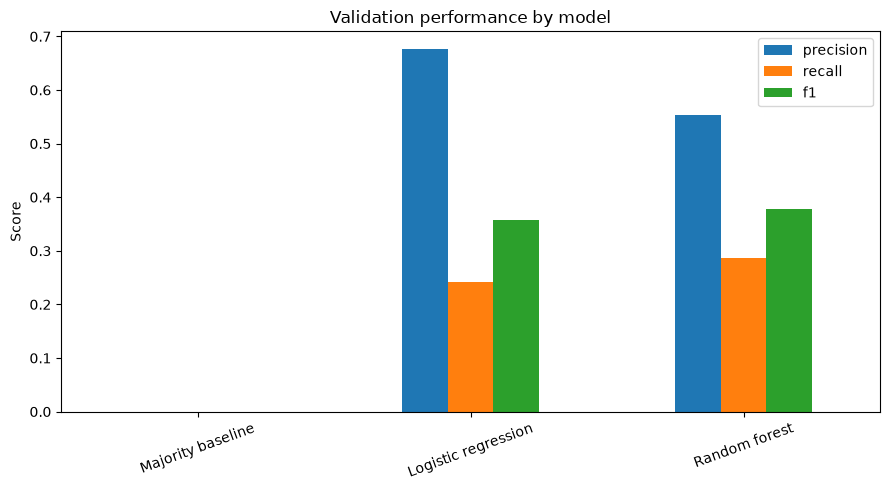

In [47]:

comparison = pd.DataFrame({
    "Majority baseline": evaluate(baseline, X_val, y_val),
    "Logistic regression": evaluate(logistic, X_val, y_val),
    "Random forest": evaluate(forest, X_val, y_val),
}).T

comparison[["precision", "recall", "f1"]].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Score")
plt.title("Validation performance by model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


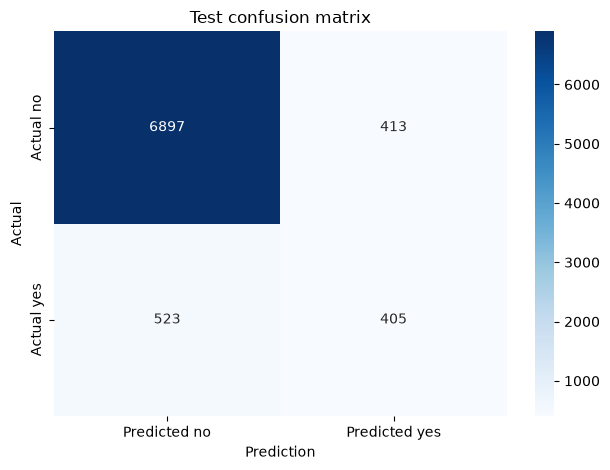

In [48]:
cm = confusion_matrix(y_test, test_predictions)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted no", "Predicted yes"],
    yticklabels=["Actual no", "Actual yes"]
)
plt.title("Test confusion matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


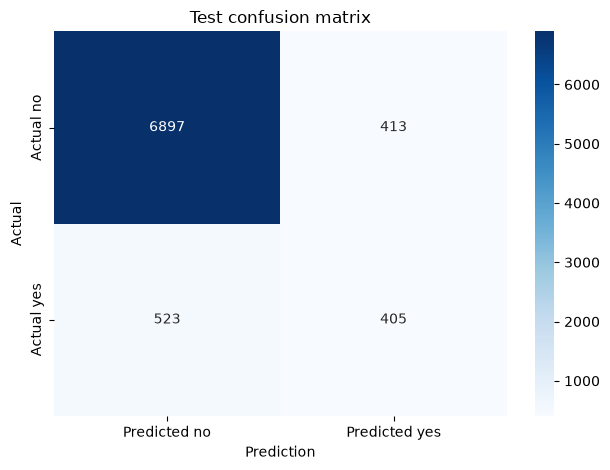

In [ ]:

cm = confusion_matrix(y_test, test_predictions)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted no", "Predicted yes"],
    yticklabels=["Actual no", "Actual yes"]
)
plt.title("Test confusion matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [50]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test
error_analysis["predicted"] = test_predictions
error_analysis["probability_yes"] = test_probabilities

false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))
print(false_positives.head())
print(false_negatives.head())


False positives: 413
False negatives: 523
       age         job   marital          education default housing loan  \
27902   70   housemaid   married           basic.4y      no      no   no   
40531   33  unemployed    single           basic.9y      no     yes   no   
38371   32    services   married        high.school      no      no   no   
37792   51      admin.  divorced        high.school      no      no   no   
39128   59  management   married  university.degree      no      no   no   

         contact month day_of_week  ...  previous     poutcome  emp.var.rate  \
27902   cellular   mar         thu  ...         1      failure          -1.8   
40531  telephone   aug         tue  ...         0  nonexistent          -1.7   
38371   cellular   oct         mon  ...         0  nonexistent          -3.4   
37792   cellular   aug         tue  ...         2      failure          -2.9   
39128   cellular   dec         thu  ...         1      failure          -3.0   

      cons.price.idx